<a href="https://colab.research.google.com/github/subhrajit77/Palm-Plant-Disease-detection-using-ML-DL/blob/main/Palm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# General
import os
import shutil
import random
import numpy as np

# Image processing
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

# Model building
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# For splitting data
from sklearn.model_selection import train_test_split

In [ ]:
# Your RAW data folder (change if needed)
raw_data_path = '/content/drive/MyDrive/Raw Data'

# Processed data folder
processed_data_path = '/content/drive/MyDrive/Final_Data'

# Folders for train, val, test
train_dir = os.path.join(processed_data_path, 'train')
val_dir = os.path.join(processed_data_path, 'val')
test_dir = os.path.join(processed_data_path, 'test')

# Classes
classes = ['Healthy', 'Stage1', 'Stage2', 'Stage3']

# Create folders
for dir_path in [train_dir, val_dir, test_dir]:
    for class_name in classes:
        os.makedirs(os.path.join(dir_path, class_name), exist_ok=True)


In [ ]:
def split_data(class_folder, train_ratio=0.7, val_ratio=0.1, test_ratio=0.2):
    images = os.listdir(os.path.join(raw_data_path, class_folder))
    random.shuffle(images)

    total_images = len(images)
    train_count = int(total_images * train_ratio)
    val_count = int(total_images * val_ratio)

    train_images = images[:train_count]
    val_images = images[train_count:train_count+val_count]
    test_images = images[train_count+val_count:]

    for image in train_images:
        shutil.copy(os.path.join(raw_data_path, class_folder, image),
                    os.path.join(train_dir, class_folder, image))

    for image in val_images:
        shutil.copy(os.path.join(raw_data_path, class_folder, image),
                    os.path.join(val_dir, class_folder, image))

    for image in test_images:
        shutil.copy(os.path.join(raw_data_path, class_folder, image),
                    os.path.join(test_dir, class_folder, image))

# Apply splitting for all classes
for class_name in classes:
    split_data(class_name)


In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

# Define paths
base_dir = '/content/drive/MyDrive/Final_Data'  # update if needed
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Image settings
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Simple preprocessing without augmentation
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Generators
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 1510 images belonging to 4 classes.
Found 215 images belonging to 4 classes.
Found 436 images belonging to 4 classes.


Augmentation

In [ ]:
import os
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

# Define augmentation generator
augmentor = ImageDataGenerator(
    rotation_range=20,              # rotate up to 20 degrees
    width_shift_range=0.1,           # shift horizontally up to 10%
    height_shift_range=0.1,          # shift vertically up to 10%
    zoom_range=0.2,                  # zoom in/out by 20%
    shear_range=0.1,                 # shear transformation
    horizontal_flip=True,            # horizontal flip
    fill_mode='nearest',             # fill missing pixels after transformation
    brightness_range=[0.7, 1.3],     # vary brightness between 70% (darker) and 130% (brighter)
    channel_shift_range=30.0         # random shift in the RGB color channels to simulate contrast variations
)

# Paths
train_dir = '/content/drive/MyDrive/Final_Data/train'  # update if needed
classes = ['Healthy', 'Stage1', 'Stage2', 'Stage3']  # class folder names

# Augment training images
def augment_class_images(class_folder, augment_times=3):  # 3 augmented per image
    class_path = os.path.join(train_dir, class_folder)
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]

    for img_name in tqdm(images, desc=f'Augmenting {class_folder}'):
        img_path = os.path.join(class_path, img_name)
        img = load_img(img_path)
        x = img_to_array(img)
        x = x.reshape((1,) + x.shape)

        base_name = os.path.splitext(img_name)[0]

        i = 0
        for batch in augmentor.flow(x, batch_size=1):
            i += 1
            aug_img_name = f'{base_name}_aug{i}.jpg'
            save_path = os.path.join(class_path, aug_img_name)
            save_img(save_path, batch[0].astype('uint8'))
            if i >= augment_times:
                break

# Run augmentation for all classes
for class_name in classes:
    augment_class_images(class_name)


Augmenting Stage3: 100%|██████████| 200/200 [00:16<00:00, 12.48it/s]


In [ ]:
# prompt: count total number of images in train folder

import os

train_dir = '/content/drive/MyDrive/Final_Data/train'
image_extensions = ('.jpg', '.jpeg', '.png')  # Add other extensions if needed

total_images = 0
for class_folder in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_folder)
    if os.path.isdir(class_path):  # Ensure it's a directory, not a file
        for filename in os.listdir(class_path):
            if filename.lower().endswith(image_extensions):
                total_images += 1
print(f"Total number of images in the 'train' folder: {total_images}")


Total number of images in the 'train' folder: 6040


Build VGG16


In [ ]:
# Load base VGG16 model (without top)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers on top
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(len(classes), activation='softmax')(x)

# Full model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,500 (80.64 MB)

 Trainable params: 6,423,812 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Train model

In [ ]:
# Callbacks
# early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# checkpoint = ModelCheckpoint('vgg16_best_model.h5', monitor='val_accuracy', save_best_only=True)

# Train
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100
    # callbacks=[early_stop, checkpoint]
)


Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 186ms/step - accuracy: 0.9974 - loss: 0.0144 - val_accuracy: 1.0000 - val_loss: 0.0038
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 191ms/step - accuracy: 0.9972 - loss: 0.0081 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 189ms/step - accuracy: 0.9963 - loss: 0.0090 - val_accuracy: 0.9860 - val_loss: 0.0249
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 186ms/step - accuracy: 0.9978 - loss: 0.0109 - val_accuracy: 0.9860 - val_loss: 0.0253
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 194ms/step - accuracy: 0.9867 - loss: 0.0748 - val_accuracy: 0.9907 - val_loss: 0.0694
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 205ms/step - accuracy: 0.9916 - loss: 0.0687 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 214ms/step - accuracy: 0.9938 - loss: 0.0182 - val_accuracy: 0.9767 - val_loss: 0.0703
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 184ms/step - accuracy: 0.9834 - loss: 0.1235 - val_ac

In [ ]:
# Save the entire model after training
model.save('wsd_detection_model.h5')
print("Model saved successfully as 'wsd_detection_model.h5'")


Model saved successfully as 'wsd_detection_model.h5'


In [ ]:
# Evaluate
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 698ms/step - accuracy: 0.9958 - loss: 0.2405
Test Accuracy: 99.08%


14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 309ms/step


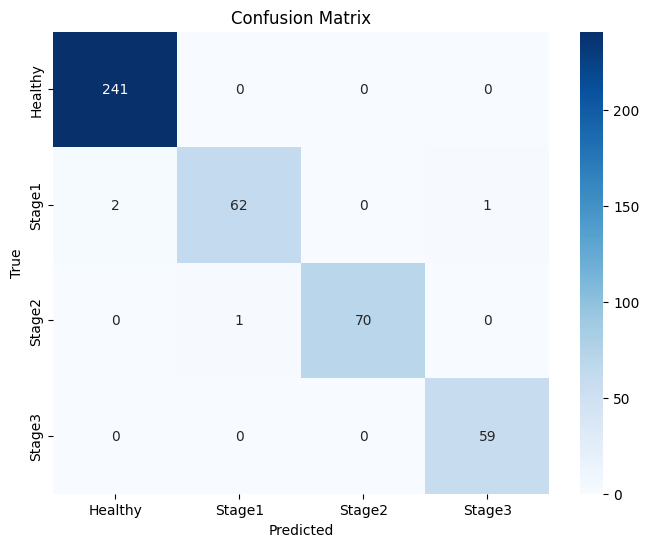


Classification Report:

              precision    recall  f1-score   support

     Healthy       0.99      1.00      1.00       241
      Stage1       0.98      0.95      0.97        65
      Stage2       1.00      0.99      0.99        71
      Stage3       0.98      1.00      0.99        59

    accuracy                           0.99       436
   macro avg       0.99      0.98      0.99       436
weighted avg       0.99      0.99      0.99       436



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get true labels and predicted labels
# Predict the classes
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

# Get true labels
y_true = test_generator.classes

# Get class labels (order must match the test_generator's class_indices)
class_labels = list(test_generator.class_indices.keys())

# 2. Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# 4. Optional: Print classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))


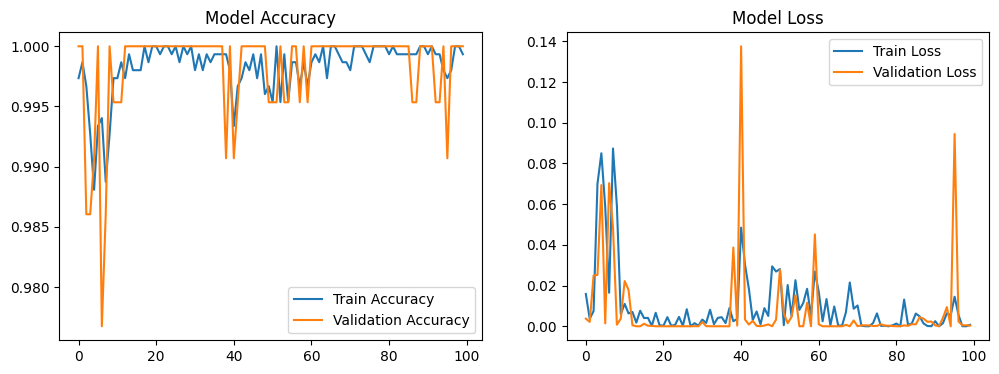

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")
plt.show()

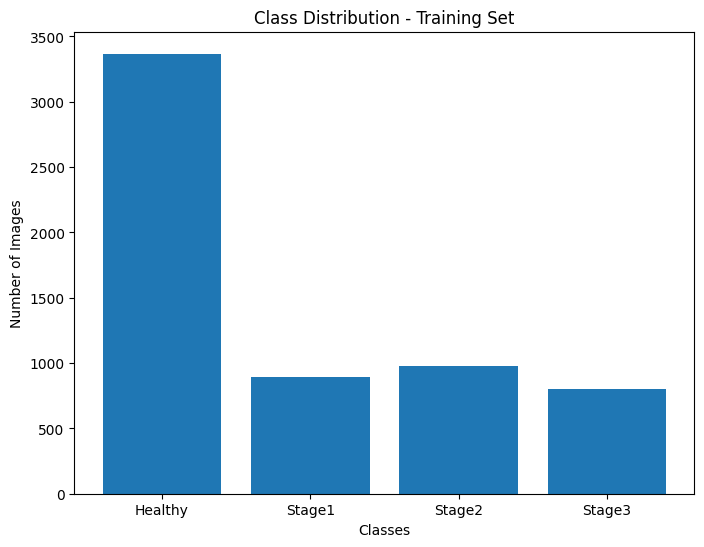

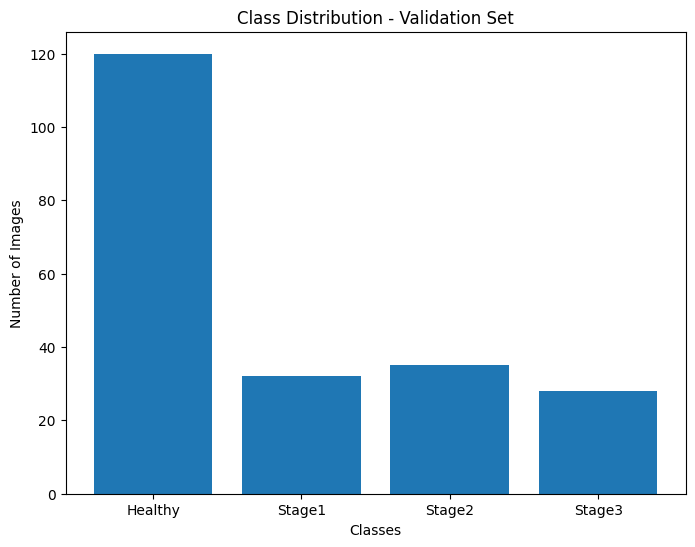

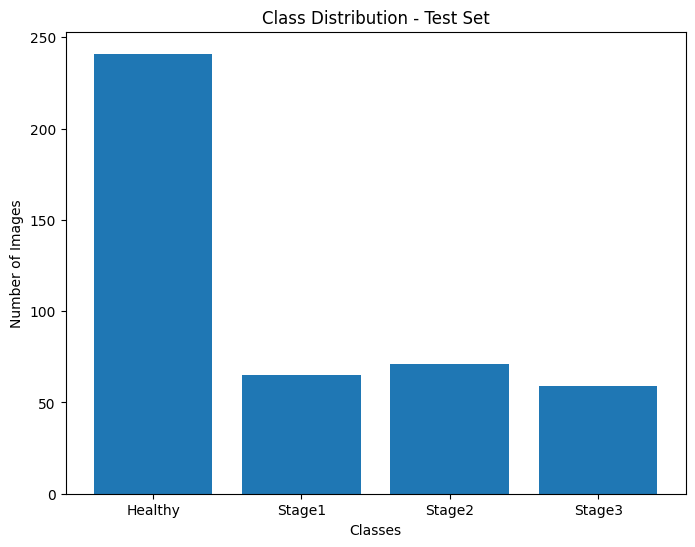

In [ ]:

import matplotlib.pyplot as plt

def plot_class_distribution(directory, title):
    class_counts = {}
    for class_folder in os.listdir(directory):
      class_path = os.path.join(directory, class_folder)
      if os.path.isdir(class_path):
          class_counts[class_folder] = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path,f))])

    plt.figure(figsize=(8,6))
    plt.bar(class_counts.keys(), class_counts.values())
    plt.title(f"Class Distribution - {title}")
    plt.xlabel("Classes")
    plt.ylabel("Number of Images")
    plt.show()


plot_class_distribution(train_dir, "Training Set")
plot_class_distribution(val_dir, "Validation Set")
plot_class_distribution(test_dir, "Test Set")



XAI


In [ ]:

from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np

def predict_on_image(image_path, model):
    img = image.load_img(image_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    preds = model.predict(x)
    class_idx = np.argmax(preds[0])
    class_labels = list(test_generator.class_indices.keys())

    predicted_class = class_labels[class_idx]
    confidence = preds[0][class_idx]

    print(f"Predicted class: {predicted_class}")
    print(f"Confidence: {confidence:.2f}")

    return predicted_class, confidence

# Load your trained model
from tensorflow.keras.models import load_model
model = load_model('wsd_detection_model.h5')


image_path = '/content/drive/MyDrive/Final_Data/test/Stage1/wsphase1-489.jpg'
predicted_class, confidence = predict_on_image(image_path, model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted class: Stage1
Confidence: 1.00


In [ ]:
image_path = '/content/drive/MyDrive/Final_Data/test/Stage2/wsphase2-572.jpg'
predicted_class, confidence = predict_on_image(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted class: Stage2
Confidence: 1.00


In [ ]:
image_path = '/content/drive/MyDrive/ML/sample-image-3.jpg'
predicted_class, confidence = predict_on_image(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted class: Stage3
Confidence: 1.00


In [ ]:
image_path = '/content/drive/MyDrive/ML/test-image-5.jpeg'
predicted_class, confidence = predict_on_image(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted class: Healthy
Confidence: 1.00


In [ ]:
image_path = '/content/drive/MyDrive/ML/new-test.jpeg'
predicted_class, confidence = predict_on_image(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Predicted class: Healthy
Confidence: 1.00


In [ ]:
import os

train_dir = '/content/drive/MyDrive/Final_Data/train'
image_extensions = ('.jpg', '.jpeg', '.png')  # Add other extensions if needed

total_images = 0
for class_folder in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_folder)
    if os.path.isdir(class_path):  # Ensure it's a directory, not a file
        for filename in os.listdir(class_path):
            if filename.lower().endswith(image_extensions):
                total_images += 1
print(f"Total number of images in the 'train' folder: {total_images}")


Total number of images in the 'train' folder: 6040


In [ ]:
import os

def get_file_address(filename):
  """
  Prints the absolute path of a file in the current working directory.

  Args:
    filename: The name of the file.

  Returns:
    The absolute path of the file, or None if the file is not found.
  """
  try:
    file_path = os.path.abspath(filename)
    print(f"The address of '{filename}' is: {file_path}")
    return file_path
  except FileNotFoundError:
    print(f"Error: File '{filename}' not found.")
    return None

# Example usage:
file_name = "wsd_detection_model.h5"  # Replace with the actual file name
get_file_address("wsd_detection_model.h5")

The address of 'wsd_detection_model.h5' is: /content/wsd_detection_model.h5


'/content/wsd_detection_model.h5'